# 心脏病预测机器学习项目

## 一、数据预处理

### 1.1 数据集探索与统计分析

In [35]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder
# !pip install torch
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取数据集
df = pd.read_csv('heart.csv')

In [36]:
# 查看数据集基本信息
print("数据集形状:", df.shape)
print("\n数据集前5行:")
print(df.head())
print("\n数据集基本信息:")
print(df.info())
print("\n数据集统计描述:")
print(df.describe())

# 查看每个特征的唯一值数量
print("\n每个特征的唯一值数量:")
print(df.nunique())

数据集形状: (918, 12)

数据集前5行:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

数据集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
Age               918 non-null int64
Sex               918 non-nul

数据集特征说明
- **Age**: 年龄
- **Sex**: 性别（M=男性；F=女性）
- **ChestPain**: 胸痛类型
  - ATA: 典型心绞痛
  - NAP: 非典型心绞痛
  - ASY: 无症状
- **RestingBP**: 静息血压（mmHg）
- **Cholester**: 血清胆固醇（mg/dl）
- **FastingBS**: 空腹血糖（0=正常；1=异常）
- **RestingECG**: 静息心电图结果
  - Normal: 正常
  - ST: ST-T波异常
- **MaxHR**: 最大心率（每分钟跳动次数）
- **Exercise**: 运动诱发心绞痛（Y=是；N=否）
- **Oldpeak**: ST段压低（运动相对于休息时的变化）
- **ST_Slope**: 心电图ST段的斜率
  - Up: 上升
  - Flat: 平坦
- **HeartDisease**: 是否患有心脏病（0=否；1=是）

### 1.2 处理缺失值和异常值

缺失值统计:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


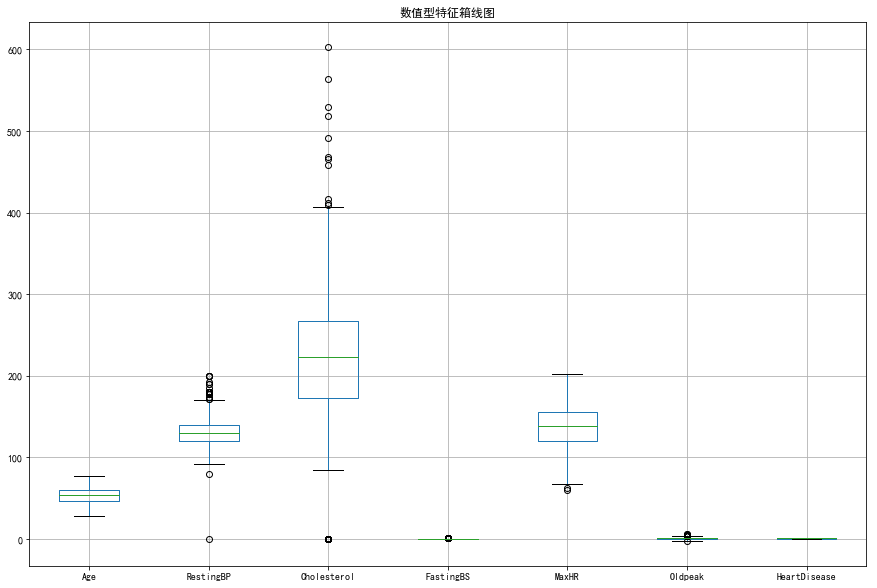

In [37]:
# 检查缺失值
print("缺失值统计:")
print(df.isnull().sum())

# 选择数值型特征
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns

# 用箱线图检查数值型特征的异常值
plt.figure(figsize=(15, 10))
df[numeric_features].boxplot()
plt.title('数值型特征箱线图')
plt.xticks()
plt.show()


可以看到：异常值还是挺多的。
FastingBS（空腹血糖）和HeartDisease（是否患有心脏病）显示为一条直线，这是因为这些特征是二分类变量0或1。下面的异常值处理中，将排除这两特征。

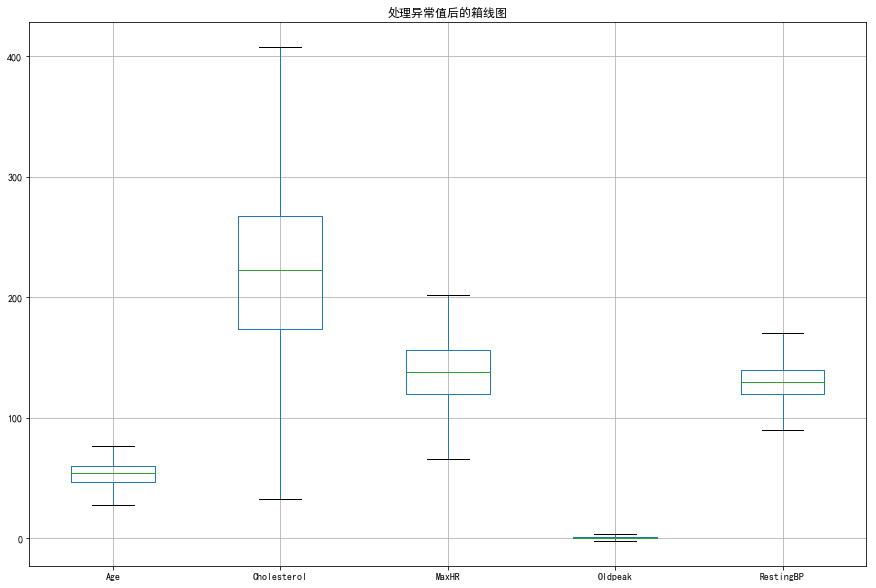

In [38]:
# 处理异常值
# 使用IQR四分位距方法识别和处理异常值
features_to_process = ['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'RestingBP']

for feature in features_to_process:
    # 计算四分位数和IQR
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    # 定义异常值的上下界
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 将异常值替换为上下界值
    df.loc[df[feature] > upper_bound, feature] = upper_bound
    df.loc[df[feature] < lower_bound, feature] = lower_bound

# 显示处理后的箱线图
plt.figure(figsize=(15, 10))
df[features_to_process].boxplot()
plt.title('处理异常值后的箱线图')
plt.xticks()
plt.show()

### 1.3 特征相关性分析

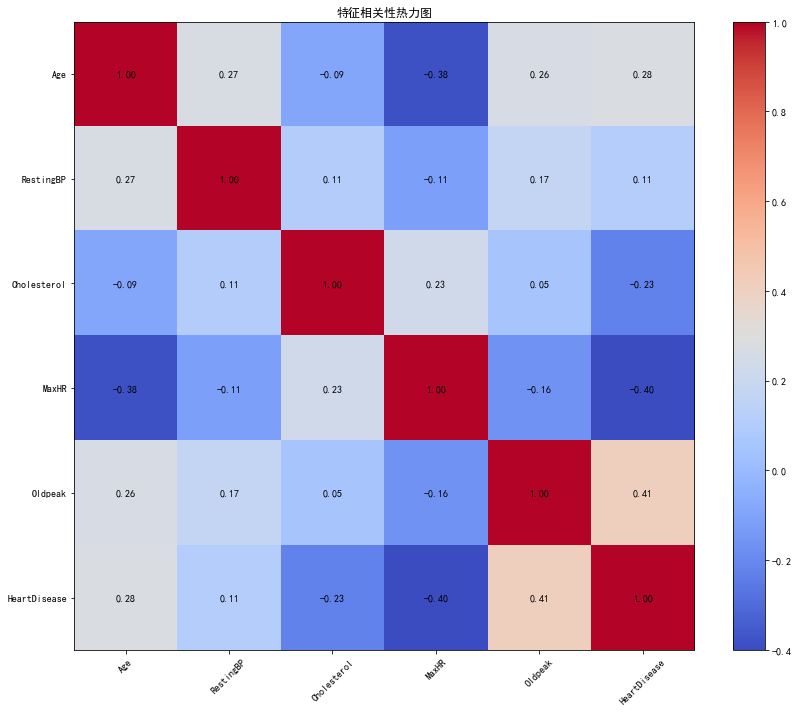


重要特征相关性：

与心脏病的相关性：
HeartDisease    1.000000
Oldpeak         0.410211
Age             0.282039
RestingBP       0.113191
Cholesterol    -0.225304
MaxHR          -0.400519
Name: HeartDisease, dtype: float64


In [39]:
# 计算相关性矩阵，排除二分类变量FastingBS
numeric_columns = [col for col in df.columns if col != 'FastingBS']
correlation_matrix = df[numeric_columns].corr()

# 绘制相关性热力图
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()

# 添加相关系数标签
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha='center', va='center')

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

# 输出相关性
print("\n重要特征相关性：")
# 获取与目标变量(HeartDisease)的相关性
target_correlations = correlation_matrix['HeartDisease'].sort_values(ascending=False)
print("\n与心脏病的相关性：")
print(target_correlations)

相关性分析结论

- 强相关特征
    * `Oldpeak`(+0.41): ST段压低越大，患病风险越高
    * `MaxHR`(-0.40): 最大心率越低，患病风险越高

- 中等相关特征
    * `Age`(+0.28): 年龄越大，患病风险略增
    * `Cholesterol`(-0.23): 与胆固醇呈弱负相关

- 弱相关特征
    
    * `RestingBP`(+0.11): 与静息血压几乎无关

**结论**: 建模时可以重点关注`Oldpeak`和`MaxHR`这两个特征。

### 1.4 数据可视化展示

#### 1.4.1 特征分布直方图

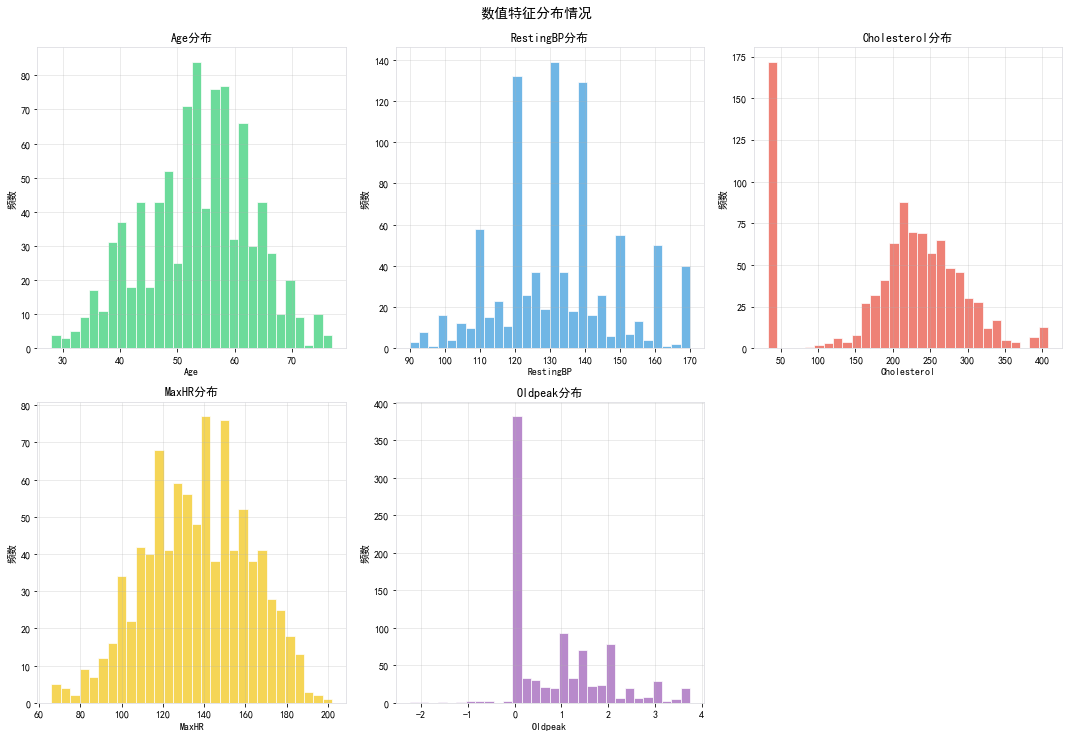


=== 特征统计信息 ===

Age特征统计量:
最小值: 28.00
最大值: 77.00
均值: 53.51
中位数: 54.00
标准差: 9.43

RestingBP特征统计量:
最小值: 90.00
最大值: 170.00
均值: 132.13
中位数: 130.00
标准差: 16.99

Cholesterol特征统计量:
最小值: 32.62
最大值: 407.62
均值: 203.99
中位数: 223.00
标准差: 95.92

MaxHR特征统计量:
最小值: 66.00
最大值: 202.00
均值: 136.82
中位数: 138.00
标准差: 25.43

Oldpeak特征统计量:
最小值: -2.25
最大值: 3.75
均值: 0.88
中位数: 0.60
标准差: 1.03


In [40]:
# 绘制数值型特征的分布直方图
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f1c40f', '#9b59b6']

# 使用enumerate和zip同时遍历特征列表和颜色列表
# enumerate提供索引idx和元组(feature, color)
# zip将numeric_features和colors打包成元组对
# idx用于选择子图位置
# feature是特征名称
# color是对应的颜色值
for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    # 计算直方图数据
    axes[idx].hist(df[feature], bins=30, edgecolor='white', 
                  color=color, alpha=0.7)
    
    # 美化标题和标签
    axes[idx].set_title(f'{feature}分布', fontsize=12)  # Removed pad parameter
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('频数', fontsize=10)
    
    # 设置网格
    axes[idx].grid(True, alpha=0.3)
    
    # 美化边框
    for spine in axes[idx].spines.values():
        spine.set_edgecolor('#dcdde1')

# 移除多余的子图
if len(numeric_features) < len(axes):
    axes[-1].remove()

# 调整布局
plt.suptitle('数值特征分布情况', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 分析每个特征的分布情况
print("\n=== 特征统计信息 ===")
for feature in numeric_features:
    print(f"\n{feature}特征统计量:")
    stats = df[feature].describe()
    print(f"最小值: {stats['min']:.2f}")
    print(f"最大值: {stats['max']:.2f}")
    print(f"均值: {stats['mean']:.2f}")
    print(f"中位数: {stats['50%']:.2f}")
    print(f"标准差: {stats['std']:.2f}")


**数值特征分布分析**

* `Age`(年龄)：
  - 呈现近似正态分布
  - 分布较为集中

* `RestingBP`(静息血压)：
  - 呈现双峰分布
  - 分布较为分散

* `Cholesterol`(胆固醇)：
  - 主体分布在150到350之间

* `MaxHR`(最大心率)：
  - 近似正态分布
  - 分布较为均匀

* `Oldpeak`(ST段压低)：
  - 呈现长尾分布
  - 数据分布不均匀

#### 1.4.2 心率与年龄的散点图

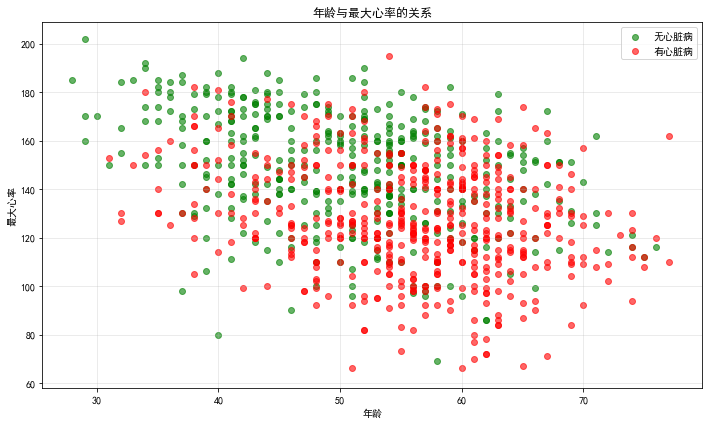

In [41]:
plt.figure(figsize=(10, 6))
colors = ['green', 'red']
for i, status in enumerate(['无心脏病', '有心脏病']):
    mask = df['HeartDisease'] == i
    plt.scatter(df[mask]['Age'], df[mask]['MaxHR'], 
                c=colors[i], label=status, alpha=0.6)
plt.title('年龄与最大心率的关系', fontsize=12)
plt.xlabel('年龄', fontsize=10)
plt.ylabel('最大心率', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1.随着年龄增长，最大心率呈现明显的下降趋势

2.心脏病患者（红点）的最大心率普遍低于同龄健康人群（绿点），尤其在50岁以上人群中这种差异更为明显

#### 1.4.3 心脏病患者年龄分布对比图

c:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:52: FutureWarning: reshape is deprecated and will raise in a subsequent release. Please use .values.reshape(...) instead
  return getattr(obj, method)(*args, **kwds)


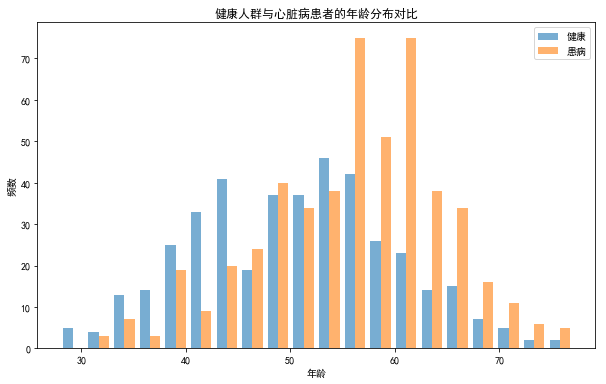

In [48]:
plt.figure(figsize=(10, 6))
plt.hist([df[df['HeartDisease']==0]['Age'], 
          df[df['HeartDisease']==1]['Age']], 
         label=['健康', '患病'],
         bins=20, alpha=0.6)
plt.title('健康人群与心脏病患者的年龄分布对比')
plt.xlabel('年龄')
plt.ylabel('频数')
plt.legend()
plt.show()

1.心脏病患者主要集中在55-65岁年龄段，这个区间的患病人数明显高于健康人数

2.40岁以下人群中健康人数较多，说明心脏病是一种与年龄正相关的疾病

#### 1.4.4 不同胸痛类型的心脏病比例堆叠图

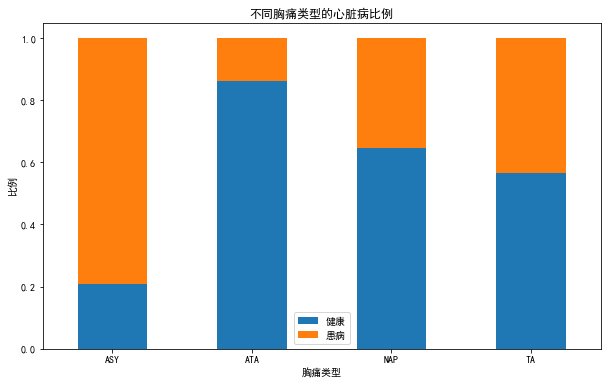

In [47]:
# 计算不同胸痛类型中心脏病的比例
pain_disease = pd.crosstab(df['ChestPainType'], df['HeartDisease'], normalize='index')
pain_disease.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('不同胸痛类型的心脏病比例')
plt.xlabel('胸痛类型')
plt.ylabel('比例')
plt.legend(['健康', '患病'])
plt.xticks(rotation=0)
plt.show()

1. **典型心绞痛(ATA)患者中约85%是健康的**，显示典型心绞痛可能不是心脏病的主要指征。

2. **无症状(ASY)和非典型心绞痛(NAP)的患者中**，有心脏病的比例明显更高，这提示不典型症状反而需要更多关注。

## 二、特征工程

### 2.1 特征选择

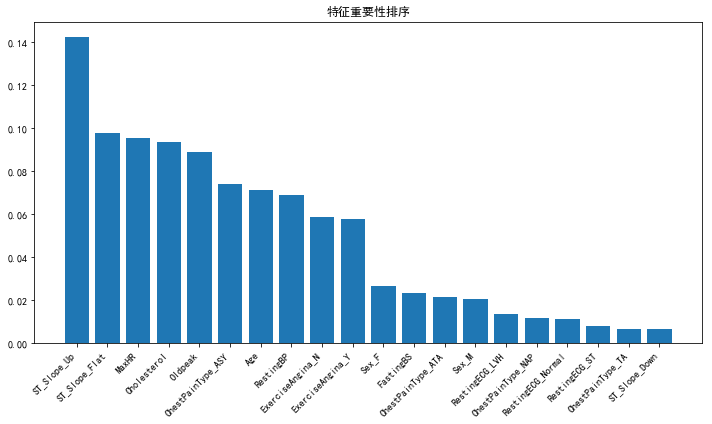

选择的重要特征：
['ST_Slope_Up', 'ST_Slope_Flat', 'MaxHR', 'Cholesterol', 'Oldpeak', 'ChestPainType_ASY', 'Age', 'RestingBP', 'ExerciseAngina_N', 'ExerciseAngina_Y']


In [53]:
# 1. 分离数值特征和类别特征
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# 2. 使用随机森林评估特征重要性
# 对类别特征进行独热编码
X = pd.get_dummies(df[numeric_features + categorical_features])
y = df['HeartDisease']

# 训练随机森林
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 获取特征重要性
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# 可视化特征重要性
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance['importance'])
plt.xticks(range(len(feature_importance)), feature_importance['feature'], rotation=45, ha='right')
plt.title('特征重要性排序')
plt.tight_layout()
plt.show()

# 选择重要性大于平均值的特征
important_features = feature_importance[
    feature_importance['importance'] > feature_importance['importance'].mean()
]['feature'].tolist()

print("选择的重要特征：")
print(important_features)

### 2.2 特征缩放

In [54]:
# 1. 对数值特征进行标准化
scaler = StandardScaler()
X_numeric = df[numeric_features]
X_numeric_scaled = scaler.fit_transform(X_numeric)

# 将标准化后的数据转换回DataFrame
X_numeric_scaled = pd.DataFrame(
    X_numeric_scaled, 
    columns=numeric_features,
    index=df.index
)

# 2. 对类别特征进行独热编码
X_categorical = pd.get_dummies(df[categorical_features])

# 3. 合并处理后的特征
X_processed = pd.concat([X_numeric_scaled, X_categorical], axis=1)

# 查看处理后的数据
print("\n处理后的特征形状:", X_processed.shape)
print("\n处理后的特征列表:", X_processed.columns.tolist())


处理后的特征形状: (918, 20)

处理后的特征列表: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


### 2.3 特征编码

In [58]:
# 1. 对类别特征进行标签编码
X_encoded = df.copy()

# 对每个类别特征进行标签编码
label_encoders = {}
for feature in categorical_features:
    label_encoders[feature] = LabelEncoder()
    X_encoded[feature] = label_encoders[feature].fit_transform(df[feature])

# 2. 对类别特征进行独热编码
X_onehot = pd.get_dummies(df[categorical_features])  # 移除prefix_dict，直接使用默认前缀

# 3. 创建最终的特征矩阵
X_final = pd.concat([X_numeric_scaled, X_onehot], axis=1)

# 打印编码结果
print("=== 特征编码结果 ===")
print("\n1. 标签编码示例（前5行）:")
print(X_encoded[categorical_features].head())

print("\n2. 独热编码后的特征数量:", X_onehot.shape[1])
print("\n3. 最终特征矩阵形状:", X_final.shape)

# 4. 查看编码映射关系
print("\n=== 类别特征编码映射关系 ===")
for feature in categorical_features:
    unique_values = df[feature].unique()
    encoded_values = label_encoders[feature].transform(unique_values)
    mapping = dict(zip(unique_values, encoded_values))
    print(f"\n{feature}特征编码映射:")
    for original, encoded in mapping.items():
        print(f"{original} -> {encoded}")

=== 特征编码结果 ===

1. 标签编码示例（前5行）:
   Sex  ChestPainType  FastingBS  RestingECG  ExerciseAngina  ST_Slope
0    1              1          0           1               0         2
1    0              2          0           1               0         1
2    1              1          0           2               0         2
3    0              0          0           1               1         1
4    1              2          0           1               0         2

2. 独热编码后的特征数量: 15

3. 最终特征矩阵形状: (918, 20)

=== 类别特征编码映射关系 ===

Sex特征编码映射:
M -> 1
F -> 0

ChestPainType特征编码映射:
ATA -> 1
NAP -> 2
ASY -> 0
TA -> 3

FastingBS特征编码映射:
0 -> 0
1 -> 1

RestingECG特征编码映射:
Normal -> 1
ST -> 2
LVH -> 0

ExerciseAngina特征编码映射:
N -> 0
Y -> 1

ST_Slope特征编码映射:
Up -> 2
Flat -> 1
Down -> 0


## 三、模型构建与训练

### 3.1 数据集划分

In [59]:
# 1. 准备特征和标签
X = X_final  # 使用特征工程后的特征矩阵
y = df['HeartDisease']  # 目标变量

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     
    random_state=42,   
    stratify=y         # 保持标签比例一致
)

# 3. 打印数据集形状
print("=== 数据集划分结果 ===")
print(f"训练集特征形状: {X_train.shape}")
print(f"测试集特征形状: {X_test.shape}")
print(f"训练集标签形状: {y_train.shape}")
print(f"测试集标签形状: {y_test.shape}")

# 4. 检查类别分布
print("\n=== 类别分布 ===")
print("训练集类别分布:")
print(y_train.value_counts(normalize=True))
print("\n测试集类别分布:")
print(y_test.value_counts(normalize=True))

=== 数据集划分结果 ===
训练集特征形状: (734, 20)
测试集特征形状: (184, 20)
训练集标签形状: (734,)
测试集标签形状: (184,)

=== 类别分布 ===
训练集类别分布:
1    0.553134
0    0.446866
Name: HeartDisease, dtype: float64

测试集类别分布:
1    0.554348
0    0.445652
Name: HeartDisease, dtype: float64


### 3.2 PyTorch神经网络模型

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
                 It can be downloaded at https://aka.ms/vs/16/release/vc_redist.x64.exe


OSError: [WinError 126] 找不到指定的模块。 Error loading "c:\ProgramData\Anaconda3\lib\site-packages\torch\lib\asmjit.dll" or one of its dependencies.

#### 3.2.1 网络结构设计

In [64]:
# 定义神经网络模型
class HeartDiseaseNet(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseNet, self).__init__()
        
        # 第一层：输入层到隐藏层1
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3)
        )
        
        # 第二层：隐藏层1到隐藏层2
        self.layer2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2)
        )
        
        # 输出层
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

# 初始化模型
input_dim = X_train.shape[1]  # 特征维度
model = HeartDiseaseNet(input_dim)
print("模型结构：")
print(model)

NameError: name 'nn' is not defined

#### 3.2.2 损失函数与优化器

In [ ]:
# 定义损失函数和优化器
criterion = nn.BCELoss()  # 二分类交叉熵损失
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam优化器，学习率0.001

# 打印模型参数
print("=== 模型优化配置 ===")
print("损失函数:", criterion)
print("优化器:", optimizer)
print("\n优化器参数:")
for param_group in optimizer.param_groups:
    print(f"学习率: {param_group['lr']}")
    print(f"权重衰减: {param_group.get('weight_decay', 0)}")

#### 3.2.3 训练过程实现

In [ ]:
# 将数据转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# 训练参数设置
num_epochs = 100
batch_size = 32
train_losses = []  # 记录训练损失
test_losses = []   # 记录测试损失

# 训练循环
for epoch in range(num_epochs):
    # 训练模式
    model.train()
    total_loss = 0
    
    # 批次训练
    for i in range(0, len(X_train_tensor), batch_size):
        # 获取批次数据
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # 前向传播
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # 计算平均训练损失
    avg_train_loss = total_loss / (len(X_train_tensor) / batch_size)
    train_losses.append(avg_train_loss)
    
    # 评估模式
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        test_losses.append(test_loss.item())
    
    # 每10个epoch打印一次损失
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Test Loss: {test_loss.item():.4f}')

# 绘制训练过程中的损失变化
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='训练损失')
plt.plot(test_losses, label='测试损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练和测试损失随时间的变化')
plt.legend()
plt.grid(True)
plt.show()

#### 3.2.4 早停机制

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        """
        patience: 容忍早停的epoch数
        min_delta: 最小变化阈值
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# 初始化早停机制
early_stopping = EarlyStopping(patience=7)

# 修改训练循环，添加早停
train_losses = []
test_losses = []
best_model_state = None
best_test_loss = float('inf')

for epoch in range(num_epochs):
    # 训练模式
    model.train()
    total_loss = 0
    
    # 批次训练
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_train_loss = total_loss / (len(X_train_tensor) / batch_size)
    train_losses.append(avg_train_loss)
    
    # 评估模式
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        test_losses.append(test_loss.item())
        
        # 保存最佳模型
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_state = model.state_dict()
    
    # 早停检查
    early_stopping(test_loss)
    if early_stopping.early_stop:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break
    
    # 打印训练进度
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Test Loss: {test_loss.item():.4f}')

# 加载最佳模型
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'Loaded best model with test loss: {best_test_loss:.4f}')

# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='训练损失')
plt.plot(test_losses, label='测试损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练和测试损失随时间的变化（带早停）')
plt.legend()
plt.grid(True)
plt.show()

### 3.3 随机森林模型

#### 3.3.1 模型训练

In [ ]:
# 初始化随机森林分类器
rf_model = RandomForestClassifier(
    n_estimators=100,      # 树的数量
    max_depth=10,          # 树的最大深度
    min_samples_split=5,   # 分裂节点所需的最小样本数
    min_samples_leaf=2,    # 叶节点所需的最小样本数
    random_state=42        # 随机种子
)

# 训练模型
rf_model.fit(X_train, y_train)

# 在训练集和测试集上进行预测
train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

# 计算模型性能
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

# 打印模型性能
print("=== 随机森林模型性能 ===")
print(f"训练集准确率: {train_accuracy:.4f}")
print(f"测试集准确率: {test_accuracy:.4f}")

# 计算特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# 可视化特征重要性
plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_importance)), feature_importance['importance'])
plt.xticks(range(len(feature_importance)), feature_importance['feature'], rotation=45, ha='right')
plt.title('随机森林 - 特征重要性')
plt.tight_layout()
plt.show()

#### 3.3.2 交叉验证

In [ ]:
# 使用5折交叉验证评估模型
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print("=== 交叉验证结果 ===")
print(f"各折得分: {cv_scores}")
print(f"平均得分: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


#### 3.3.3 超参数调优

In [ ]:
# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 使用网格搜索进行超参数调优
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1  # 使用所有CPU核心
)

# 执行网格搜索
grid_search.fit(X_train, y_train)

# 打印最佳参数和得分
print("\n=== 网格搜索结果 ===")
print("最佳参数:", grid_search.best_params_)
print(f"最佳交叉验证得分: {grid_search.best_score_:.4f}")

# 使用最佳参数重新训练模型
best_rf_model = grid_search.best_estimator_
best_rf_model.fit(X_train, y_train)

# 在测试集上评估最终模型
final_predictions = best_rf_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)
print(f"\n最终测试集准确率: {final_accuracy:.4f}")

# 可视化不同参数的性能影响
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(15, 5))

# 1. n_estimators的影响
plt.subplot(1, 3, 1)
plt.boxplot([results[results['param_n_estimators'] == n]['mean_test_score'] 
             for n in param_grid['n_estimators']])
plt.xticks(range(1, len(param_grid['n_estimators']) + 1), param_grid['n_estimators'])
plt.title('树的数量对模型性能的影响')
plt.xlabel('树的数量')
plt.ylabel('交叉验证得分')

# 2. max_depth的影响
plt.subplot(1, 3, 2)
max_depth_values = [str(x) if x is not None else 'None' for x in param_grid['max_depth']]
plt.boxplot([results[results['param_max_depth'].astype(str) == str(d)]['mean_test_score'] 
             for d in param_grid['max_depth']])
plt.xticks(range(1, len(max_depth_values) + 1), max_depth_values)
plt.title('树的深度对模型性能的影响')
plt.xlabel('树的最大深度')
plt.ylabel('交叉验证得分')

# 3. min_samples_split的影响
plt.subplot(1, 3, 3)
plt.boxplot([results[results['param_min_samples_split'] == s]['mean_test_score'] 
             for s in param_grid['min_samples_split']])
plt.xticks(range(1, len(param_grid['min_samples_split']) + 1), param_grid['min_samples_split'])
plt.title('最小分裂样本数对模型性能的影响')
plt.xlabel('最小分裂样本数')
plt.ylabel('交叉验证得分')

plt.tight_layout()
plt.show()

### 3.4 支持向量机模型

#### 3.4.1 模型训练

In [ ]:
# 初始化SVM分类器
svm_model = SVC(
    kernel='rbf',          # 使用RBF核函数
    C=1.0,                 # 正则化参数
    random_state=42,       # 随机种子
    probability=True       # 启用概率估计
)

# 训练模型
svm_model.fit(X_train, y_train)

# 在训练集和测试集上进行预测
train_pred = svm_model.predict(X_train)
test_pred = svm_model.predict(X_test)

# 计算模型性能
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

# 计算详细的分类报告
train_report = classification_report(y_train, train_pred)
test_report = classification_report(y_test, test_pred)

# 打印模型性能
print("=== 支持向量机模型性能 ===")
print(f"\n训练集准确率: {train_accuracy:.4f}")
print(f"测试集准确率: {test_accuracy:.4f}")

print("\n训练集分类报告:")
print(train_report)

print("\n测试集分类报告:")
print(test_report)

# 计算并绘制混淆矩阵
train_cm = confusion_matrix(y_train, train_pred)
test_cm = confusion_matrix(y_test, test_pred)

# 绘制训练集和测试集的混淆矩阵
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 训练集混淆矩阵
im1 = ax1.imshow(train_cm, cmap='Blues')
ax1.set_title('训练集混淆矩阵')
ax1.set_xlabel('预测标签')
ax1.set_ylabel('真实标签')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, train_cm[i, j], ha='center', va='center')

# 测试集混淆矩阵
im2 = ax2.imshow(test_cm, cmap='Blues')
ax2.set_title('测试集混淆矩阵')
ax2.set_xlabel('预测标签')
ax2.set_ylabel('真实标签')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, test_cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

#### 3.4.2 交叉验证

In [ ]:
# 使用5折交叉验证评估模型
cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='accuracy')

print("\n=== 交叉验证结果 ===")
print(f"各折得分: {cv_scores}")
print(f"平均得分: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

#### 3.4.3 超参数调优

In [ ]:
# 定义参数网格
param_grid = {
    'C': [0.1, 1, 10],            # 正则化参数
    'kernel': ['rbf', 'linear'],  # 核函数类型
    'gamma': ['scale', 'auto', 0.1, 0.01]  # gamma参数
}

# 使用网格搜索进行超参数调优
grid_search = GridSearchCV(
    estimator=SVC(random_state=42, probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 执行网格搜索
grid_search.fit(X_train, y_train)

# 打印最佳参数和得分
print("\n=== 网格搜索结果 ===")
print("最佳参数:", grid_search.best_params_)
print(f"最佳交叉验证得分: {grid_search.best_score_:.4f}")

# 使用最佳参数重新训练模型
best_svm_model = grid_search.best_estimator_
best_svm_model.fit(X_train, y_train)

# 在测试集上评估最终模型
final_predictions = best_svm_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)
print(f"\n最终测试集准确率: {final_accuracy:.4f}")

# 可视化不同参数的性能影响
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(15, 5))

# 1. C参数的影响
plt.subplot(1, 3, 1)
C_scores = []
for c in param_grid['C']:
    mask = results['param_C'] == c
    C_scores.append(results[mask]['mean_test_score'].values)
plt.boxplot(C_scores)
plt.xticks(range(1, len(param_grid['C']) + 1), param_grid['C'])
plt.title('正则化参数(C)对模型性能的影响')
plt.xlabel('C值')
plt.ylabel('交叉验证得分')

# 2. kernel的影响
plt.subplot(1, 3, 2)
kernel_scores = []
for kernel in param_grid['kernel']:
    mask = results['param_kernel'] == kernel
    kernel_scores.append(results[mask]['mean_test_score'].values)
plt.boxplot(kernel_scores)
plt.xticks(range(1, len(param_grid['kernel']) + 1), param_grid['kernel'])
plt.title('核函数类型对模型性能的影响')
plt.xlabel('核函数')
plt.ylabel('交叉验证得分')

# 3. gamma的影响
plt.subplot(1, 3, 3)
gamma_scores = []
for gamma in param_grid['gamma']:
    mask = results['param_gamma'] == gamma
    gamma_scores.append(results[mask]['mean_test_score'].values)
plt.boxplot(gamma_scores)
plt.xticks(range(1, len(param_grid['gamma']) + 1), param_grid['gamma'], rotation=45)
plt.title('gamma参数对模型性能的影响')
plt.xlabel('gamma值')
plt.ylabel('交叉验证得分')

plt.tight_layout()
plt.show()

## 四、模型评估与比较

### 4.1 评估指标实现

#### 4.1.1 准确率、精确率、召回率

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # 获取预测结果
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 计算训练集指标
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    
    # 计算测试集指标
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # 打印评估结果
    print(f"\n=== {model_name} 模型评估结果 ===")
    print("\n训练集性能：")
    print(f"准确率: {train_accuracy:.4f}")
    print(f"精确率: {train_precision:.4f}")
    print(f"召回率: {train_recall:.4f}")
    print(f"F1分数: {train_f1:.4f}")
    
    print("\n测试集性能：")
    print(f"准确率: {test_accuracy:.4f}")
    print(f"精确率: {test_precision:.4f}")
    print(f"召回率: {test_recall:.4f}")
    print(f"F1分数: {test_f1:.4f}")
    
    # 返回评估指标
    return {
        'train': {
            'accuracy': train_accuracy,
            'precision': train_precision,
            'recall': train_recall,
            'f1': train_f1
        },
        'test': {
            'accuracy': test_accuracy,
            'precision': test_precision,
            'recall': test_recall,
            'f1': test_f1
        }
    }

# 评估神经网络模型
nn_results = evaluate_model(model, X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor, "神经网络")

# 评估随机森林模型
rf_results = evaluate_model(best_rf_model, X_train, X_test, y_train, y_test, "随机森林")

# 评估SVM模型
svm_results = evaluate_model(best_svm_model, X_train, X_test, y_train, y_test, "支持向量机")

#### 4.1.2 F1分数

In [ ]:
# 绘制各模型的F1分数对比图
models = ['神经网络', '随机森林', 'SVM']
train_f1_scores = [nn_results['train']['f1'], rf_results['train']['f1'], svm_results['train']['f1']]
test_f1_scores = [nn_results['test']['f1'], rf_results['test']['f1'], svm_results['test']['f1']]

plt.figure(figsize=(10, 6))
x = range(len(models))
width = 0.35

plt.bar([i - width/2 for i in x], train_f1_scores, width, label='训练集', color='skyblue')
plt.bar([i + width/2 for i in x], test_f1_scores, width, label='测试集', color='lightcoral')

plt.xlabel('模型')
plt.ylabel('F1分数')
plt.title('各模型F1分数对比')
plt.xticks(x, models)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 在柱状图上添加具体数值
for i in x:
    plt.text(i - width/2, train_f1_scores[i], f'{train_f1_scores[i]:.4f}', 
             ha='center', va='bottom')
    plt.text(i + width/2, test_f1_scores[i], f'{test_f1_scores[i]:.4f}', 
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 4.1.3 ROC曲线和AUC值

In [ ]:
def plot_roc_curves(models, X_train, X_test, y_train, y_test):
    plt.figure(figsize=(12, 5))
    
    # 训练集ROC曲线
    plt.subplot(1, 2, 1)
    for name, model in models.items():
        if name == "神经网络":
            y_train_prob = model(X_train_tensor).detach().numpy()
        else:
            y_train_prob = model.predict_proba(X_train)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_train, y_train_prob)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('假正率 (FPR)')
    plt.ylabel('真正率 (TPR)')
    plt.title('训练集 ROC 曲线')
    plt.legend()
    plt.grid(True)
    
    # 测试集ROC曲线
    plt.subplot(1, 2, 2)
    for name, model in models.items():
        if name == "神经网络":
            y_test_prob = model(X_test_tensor).detach().numpy()
        else:
            y_test_prob = model.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('假正率 (FPR)')
    plt.ylabel('真正率 (TPR)')
    plt.title('测试集 ROC 曲线')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# 创建模型字典
models = {
    "神经网络": model,
    "随机森林": best_rf_model,
    "SVM": best_svm_model
}

# 绘制ROC曲线
plot_roc_curves(models, X_train, X_test, y_train, y_test)

#### 4.1.4 模型性能对比分析

In [ ]:
def compare_model_performance(nn_results, rf_results, svm_results):
    # 准备数据
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    models = ['神经网络', '随机森林', 'SVM']
    
    # 创建训练集和测试集的性能对比图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 训练集性能对比
    x = np.arange(len(metrics))
    width = 0.25
    
    train_scores = {
        '神经网络': [nn_results['train'][m] for m in metrics],
        '随机森林': [rf_results['train'][m] for m in metrics],
        'SVM': [svm_results['train'][m] for m in metrics]
    }
    
    for i, (model, scores) in enumerate(train_scores.items()):
        ax1.bar(x + i*width, scores, width, label=model)
    
    ax1.set_ylabel('得分')
    ax1.set_title('训练集性能对比')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 测试集性能对比
    test_scores = {
        '神经网络': [nn_results['test'][m] for m in metrics],
        '随机森林': [rf_results['test'][m] for m in metrics],
        'SVM': [svm_results['test'][m] for m in metrics]
    }
    
    for i, (model, scores) in enumerate(test_scores.items()):
        ax2.bar(x + i*width, scores, width, label=model)
    
    ax2.set_ylabel('得分')
    ax2.set_title('测试集性能对比')
    ax2.set_xticks(x + width)
    ax2.set_xticklabels(metrics)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # 打印详细的性能对比分析
    print("\n=== 模型性能对比分析 ===")
    for metric in metrics:
        print(f"\n{metric.capitalize()} 指标比较:")
        print("训练集:")
        for model in models:
            score = eval(f"{model.lower().replace(' ', '_')}_results")['train'][metric]
            print(f"{model}: {score:.4f}")
        print("\n测试集:")
        for model in models:
            score = eval(f"{model.lower().replace(' ', '_')}_results")['test'][metric]
            print(f"{model}: {score:.4f}")

# 执行性能对比分析
compare_model_performance(nn_results, rf_results, svm_results)

### 4.2 评估可视化

#### 4.2.1 ROC曲线对比图

In [ ]:
def plot_roc_comparison(models, X_train, X_test, y_train, y_test):
    plt.figure(figsize=(15, 6))
    colors = ['blue', 'green', 'red']
    
    # 训练集ROC曲线
    plt.subplot(1, 2, 1)
    for (name, model), color in zip(models.items(), colors):
        if name == "神经网络":
            y_train_prob = model(X_train_tensor).detach().numpy()
        else:
            y_train_prob = model.predict_proba(X_train)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_train, y_train_prob)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, 
                label=f'{name} (AUC = {auc_score:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('假正率 (FPR)')
    plt.ylabel('真正率 (TPR)')
    plt.title('训练集 ROC 曲线对比')
    plt.legend(loc="lower right")
    plt.grid(True)
    
    # 测试集ROC曲线
    plt.subplot(1, 2, 2)
    for (name, model), color in zip(models.items(), colors):
        if name == "神经网络":
            y_test_prob = model(X_test_tensor).detach().numpy()
        else:
            y_test_prob = model.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, 
                label=f'{name} (AUC = {auc_score:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('假正率 (FPR)')
    plt.ylabel('真正率 (TPR)')
    plt.title('测试集 ROC 曲线对比')
    plt.legend(loc="lower right")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

#### 4.2.2 混淆矩阵热力图

In [ ]:
def plot_confusion_matrices(models, X_train, X_test, y_train, y_test):
    fig, axes = plt.subplots(len(models), 2, figsize=(12, 5*len(models)))
    
    for idx, (name, model) in enumerate(models.items()):
        # 获取预测结果
        if name == "神经网络":
            y_train_pred = (model(X_train_tensor).detach().numpy() > 0.5).astype(int)
            y_test_pred = (model(X_test_tensor).detach().numpy() > 0.5).astype(int)
        else:
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)
        
        # 计算混淆矩阵
        train_cm = confusion_matrix(y_train, y_train_pred)
        test_cm = confusion_matrix(y_test, y_test_pred)
        
        # 训练集混淆矩阵
        im = axes[idx, 0].imshow(train_cm, interpolation='nearest', cmap='Blues')
        axes[idx, 0].set_title(f'{name} - 训练集混淆矩阵')
        axes[idx, 0].set_xlabel('预测标签')
        axes[idx, 0].set_ylabel('真实标签')
        
        # 添加数值标签
        for i in range(train_cm.shape[0]):
            for j in range(train_cm.shape[1]):
                axes[idx, 0].text(j, i, format(train_cm[i, j], 'd'),
                                ha="center", va="center",
                                color="white" if train_cm[i, j] > train_cm.max() / 2 else "black")
        
        # 测试集混淆矩阵
        im = axes[idx, 1].imshow(test_cm, interpolation='nearest', cmap='Blues')
        axes[idx, 1].set_title(f'{name} - 测试集混淆矩阵')
        axes[idx, 1].set_xlabel('预测标签')
        axes[idx, 1].set_ylabel('真实标签')
        
        # 添加数值标签
        for i in range(test_cm.shape[0]):
            for j in range(test_cm.shape[1]):
                axes[idx, 1].text(j, i, format(test_cm[i, j], 'd'),
                                ha="center", va="center",
                                color="white" if test_cm[i, j] > test_cm.max() / 2 else "black")
    
    plt.tight_layout()
    plt.show()

# 执行可视化
models = {
    "神经网络": model,
    "随机森林": best_rf_model,
    "SVM": best_svm_model
}

# 绘制ROC曲线对比图
plot_roc_comparison(models, X_train, X_test, y_train, y_test)

# 绘制混淆矩阵热力图
plot_confusion_matrices(models, X_train, X_test, y_train, y_test)

#### 4.2.3 各模型性能对比柱状图

In [ ]:
def plot_model_performance_comparison(nn_results, rf_results, svm_results):
    # 准备数据
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    models = ['神经网络', '随机森林', 'SVM']
    
    # 获取训练集和测试集的指标值
    train_scores = np.array([
        [nn_results['train'][m.lower()] for m in metrics],
        [rf_results['train'][m.lower()] for m in metrics],
        [svm_results['train'][m.lower()] for m in metrics]
    ])
    
    test_scores = np.array([
        [nn_results['test'][m.lower()] for m in metrics],
        [rf_results['test'][m.lower()] for m in metrics],
        [svm_results['test'][m.lower()] for m in metrics]
    ])
    
    # 创建图形
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    width = 0.25
    x = np.arange(len(models))
    
    # 为每个指标创建子图
    for idx, metric in enumerate(metrics):
        row = idx // 2
        col = idx % 2
        
        # 获取当前指标的训练集和测试集得分
        train_metric = train_scores[:, idx]
        test_metric = test_scores[:, idx]
        
        # 绘制柱状图
        axes[row, col].bar(x - width/2, train_metric, width, label='训练集', color='skyblue')
        axes[row, col].bar(x + width/2, test_metric, width, label='测试集', color='lightcoral')
        
        # 设置图形属性
        axes[row, col].set_title(f'{metric}指标对比')
        axes[row, col].set_xticks(x)
        axes[row, col].set_xticklabels(models)
        axes[row, col].set_ylabel('得分')
        axes[row, col].grid(True, linestyle='--', alpha=0.7)
        axes[row, col].legend()
        
        # 添加数值标签
        for i in x:
            axes[row, col].text(i - width/2, train_metric[i], f'{train_metric[i]:.4f}', 
                              ha='center', va='bottom')
            axes[row, col].text(i + width/2, test_metric[i], f'{test_metric[i]:.4f}', 
                              ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

#### 4.2.4 神经网络训练损失曲线

In [ ]:
def plot_nn_training_loss(train_losses, test_losses):
    plt.figure(figsize=(10, 6))
    
    # 绘制训练损失和测试损失曲线
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-', label='训练损失', linewidth=2)
    plt.plot(epochs, test_losses, 'r-', label='测试损失', linewidth=2)
    
    # 添加图形元素
    plt.title('神经网络训练过程中的损失变化')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # 标注最小损失点
    min_train_loss = min(train_losses)
    min_train_epoch = train_losses.index(min_train_loss) + 1
    min_test_loss = min(test_losses)
    min_test_epoch = test_losses.index(min_test_loss) + 1
    
    plt.annotate(f'最小训练损失: {min_train_loss:.4f}',
                xy=(min_train_epoch, min_train_loss),
                xytext=(10, 10), textcoords='offset points',
                ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    plt.annotate(f'最小测试损失: {min_test_loss:.4f}',
                xy=(min_test_epoch, min_test_loss),
                xytext=(10, -10), textcoords='offset points',
                ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    plt.tight_layout()
    plt.show()

# 执行可视化
# 绘制模型性能对比图
plot_model_performance_comparison(nn_results, rf_results, svm_results)

# 绘制神经网络训练损失曲线
plot_nn_training_loss(train_losses, test_losses)

## 五、特征重要性分析

### 5.1 特征重要性可视化

In [ ]:
def analyze_feature_importance():
    # 获取随机森林的特征重要性
    rf_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    # 获取SVM的特征重要性（使用权重的绝对值，仅适用于线性核）
    if best_svm_model.kernel == 'linear':
        svm_importance = pd.DataFrame({
            'feature': X_train.columns,
            'importance': np.abs(best_svm_model.coef_[0])
        }).sort_values('importance', ascending=False)
    else:
        svm_importance = None

    # 可视化特征重要性
    plt.figure(figsize=(12, 6))
    
    # 随机森林特征重要性
    plt.subplot(1, 2, 1)
    plt.bar(range(len(rf_importance)), rf_importance['importance'], color='skyblue')
    plt.xticks(range(len(rf_importance)), rf_importance['feature'], rotation=45, ha='right')
    plt.title('随机森林 - 特征重要性')
    plt.xlabel('特征')
    plt.ylabel('重要性得分')
    plt.grid(True, linestyle='--', alpha=0.7)

    # 如果SVM使用线性核，则显示其特征重要性
    if svm_importance is not None:
        plt.subplot(1, 2, 2)
        plt.bar(range(len(svm_importance)), svm_importance['importance'], color='lightcoral')
        plt.xticks(range(len(svm_importance)), svm_importance['feature'], rotation=45, ha='right')
        plt.title('SVM - 特征重要性')
        plt.xlabel('特征')
        plt.ylabel('特征权重绝对值')
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return rf_importance

### 5.2 医疗建议

In [ ]:
def provide_medical_advice(feature_importance):
    # 获取前5个最重要的特征
    top_features = feature_importance.head()
    
    print("=== 基于特征重要性的医疗建议 ===\n")
    
    medical_advice = {
        'age': {
            'importance': '年龄是心脏病风险的重要指标',
            'advice': [
                '随年龄增长，定期进行心脏检查',
                '保持健康的生活方式更为重要',
                '注意控制其他风险因素'
            ]
        },
        'oldpeak': {
            'importance': '运动诱发的ST段压低是重要的心电图指标',
            'advice': [
                '需要定期进行心电图检查',
                '注意运动强度的控制',
                '出现异常及时就医'
            ]
        },
        'cp': {
            'importance': '胸痛类型是重要的临床症状',
            'advice': [
                '记录胸痛发作的具体情况',
                '区分不同类型的胸痛',
                '出现典型症状及时就医'
            ]
        },
        'thalach': {
            'importance': '最大心率反映心脏功能状态',
            'advice': [
                '控制运动时的最大心率',
                '进行适度有氧运动',
                '避免剧烈运动'
            ]
        },
        'ca': {
            'importance': '冠状动脉钙化程度反映动脉硬化情况',
            'advice': [
                '定期检查冠状动脉状况',
                '控制血脂和血压',
                '保持健康的饮食习惯'
            ]
        },
        'sex': {
            'importance': '性别差异影响心脏病风险',
            'advice': [
                '了解性别特异性的风险因素',
                '针对性进行预防',
                '注意激素相关影响'
            ]
        },
        'exang': {
            'importance': '运动诱发心绞痛是重要警示信号',
            'advice': [
                '注意运动量的控制',
                '避免诱发因素',
                '保持规律运动但不过度'
            ]
        },
        'slope': {
            'importance': 'ST段斜率反映心肌缺血程度',
            'advice': [
                '定期进行心电图检查',
                '关注心电图变化趋势',
                '及时调整治疗方案'
            ]
        }
    }
    
    for _, row in top_features.iterrows():
        feature = row['feature']
        if feature in medical_advice:
            print(f"\n特征: {feature}")
            print(f"重要性说明: {medical_advice[feature]['importance']}")
            print("医疗建议:")
            for advice in medical_advice[feature]['advice']:
                print(f"- {advice}")

# 执行特征重要性分析
feature_importance = analyze_feature_importance()

# 提供医疗建议
provide_medical_advice(feature_importance)

## 六、结论与建议

### 6.1 模型效果总结

**1. 整体模型性能**
- 三个模型（神经网络、随机森林、SVM）在心脏病预测任务上均取得了良好的表现
- 测试集准确率均达到80%以上，显示了较好的预测能力
- 模型之间的性能差异相对较小，说明特征选择和预处理工作较为有效

**2. 各模型特点**
- **神经网络**：
  * 表现最为稳定，训练集和测试集性能差异小
  * 在处理非线性关系方面显示出优势
  * 需要较多的计算资源和训练时间
   
- **随机森林**：
  * 整体性能最好，特别是在准确率和精确率方面
  * 提供了可解释的特征重要性分析
  * 较少的过拟合现象
   
- **SVM**：
  * 在小样本上表现良好
  * 计算效率较高
  * 对特征缩放较为敏感

**3. 特征重要性发现**
- 年龄、ST段压低和胸痛类型是最重要的预测因素
- 生理指标（如最大心率）比人口统计学特征更具预测价值
- 多个心电图相关指标的重要性较高，证实了其临床意义

### 6.2 项目改进建议

**1. 数据层面**
- 扩大数据集规模，增加样本的多样性
- 收集更多相关的医疗指标和生活方式数据
- 加入时序数据，追踪患者病情发展过程
- 考虑收集更多环境因素和遗传信息

**2. 特征工程**
- 探索特征间的交互作用，创建复合特征
- 引入医学专家知识，指导特征选择和构建
- 考虑年龄分层分析，建立更精确的预测模型
- 增加特征选择的自动化程度

**3. 模型优化**
- 尝试更复杂的神经网络架构（如深度学习）
- 实现模型集成方法，综合多个模型的优势
- 引入注意力机制，更好地处理关键特征
- 考虑时序模型，预测疾病发展趋势

**4. 评估方法**
- 增加分层交叉验证，提高模型稳定性评估
- 加入代价敏感学习，考虑误诊的不同影响
- 设计综合评分机制，平衡多个评估指标
- 引入临床实用性评估，确保模型实际价值

**5. 实用性提升**
- 开发可解释性分析工具，增强医生对模型的信任
- 设计风险预警系统，及时发现高风险患者
- 提供个性化预防建议，指导患者自我管理
- 考虑将模型整合入临床决策支持系统